In [47]:
# add parent to path
import sys
from pathlib import Path

sys.path.append(Path.cwd().parent.parent.as_posix())
from demo_and_analysis.plots.utils.per_stage_data_prep import load_wandb_data

runs: list[tuple[list[str] | str, str]] = [
    # # initial submission
    # # ("i7emr9ga", "Bespoke (flat-storage)"),
    # # ("4gbvl510", "Bespoke (bespoke-storage)"),
    # ("h1mv9o9r", "Bespoke TPC-H"),  # TPC-H
    # # ("wmfzbwa4", "Bespoke TPC-H Flat"),  # TPC-H - flat storage
    # ("5qumtphx", "Bespoke CEB"),  # CEB
    # # ("nocfw51j", "Bespoke CEB Flat"),  # CEB - flat storage
    # Revision
    # ("4t7jyv2f", "Bespoke TPC-H"),  # TPC-H
    # (["5gqn8viu", "m67to2p5", "slgev39o"], "Bespoke TPC-H"),  # Rev
    (["jg4jjo9u", "86crnuc0", "3zdiw9ol", "tc2q4e36"], "Bespoke TPC-H"),
    (["5m2t5fjn", "iv5w7m07", "gava9bsh", "2h03uj74"], "Bespoke CEB"),
]


history_dict, config_dict, summary_dict, target_sf = load_wandb_data(
    runs,
    skip_cache=False,  # set to True to skip cache and fetch from W&B API
)

benchmark_name_dict = {"tpch": "TPC-H", "ceb": "CEB"}

Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/21f74321f09a12f51c273f3d499521892dba391dff5ab6eb673a44a7a001b0fa.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/532712d2907861c4bd7972ded9695a464e32cbe45a45dbabc4eab2e998ff5ba3.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/d9d6be482e0f01fd048c076a1ba8d75369053729bbb25c711294920a330b412f.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/55d752d2ee90cd93a69f9555f05f322483f3728feac2a1e47e6c09550c413d76.pkl
Combined history has 15130 rows ([5, 1544, 8310, 5271])
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/5089d5e1738d26656475a3b15f557634eef25359edcd8c0c3c6512187360cdd7.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/993b82494ba49cdcc6d8deda5d1dd7b8975b1c3e7e76964eb8a68d32270fc23a.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/598a2f88a24ed66aec7b4ee9e514a79d78b3cf8bd099856

In [48]:
import importlib

importlib.reload(sys.modules["demo_and_analysis.plots.utils.per_stage_data_prep"])

from demo_and_analysis.plots.utils.per_stage_data_prep import process_data

all_stage_speedups, stages, run_info, total_speedup_key = process_data(
    history_dict, config_dict, summary_dict, cmp_to="umbra"
)

Bespoke TPC-H: 22 queries
Bespoke CEB: 16 queries
Removing query 08a from Bespoke CEB due to extreme outlier behavior
Stage starts: {'1&2:\nStorage': 0, 'Base\nImpl.': 240, '4&5:\nPin &\nTracing': None, '+Card\nStats. Info': 2106, '+Self-\nTracing': 3463, '+Exp.\nKnowledge': 4802, '+Human-Ref.\nPrompting': 6658, '+Multi-\nThreading': 9895}
Stage starts: {'1&2:\nStorage': 0, 'Base\nImpl.': 280, '4&5:\nPin &\nTracing': None, '+Card\nStats. Info': 2685, '+Self-\nTracing': 4196, '+Exp.\nKnowledge': 5121, '+Human-Ref.\nPrompting': 6640, '+Multi-\nThreading': 8712}
All stage speedups: {'Bespoke TPC-H': {'1&2:\nStorage': {}, 'Base\nImpl.': {'001': 5.150119730185497, '002': 10.466518181818182, '003': 1.3262080050425462, '004': 1.7820675453047774, '005': 2.9344674085850557, '006': 0.1739635193133047, '007': 0.6341633333333333, '008': 1.9664844760672702, '009': 1.1178252667040987, '010': 0.4055598170302604, '011': 1.409108695652174, '012': 1.2800305828043856, '013': 0.41469438576987216, '014': 0

In [49]:
all_stage_speedups["Bespoke TPC-H"]["__commit_hash__"]

{'1&2:\nStorage': '2d81c4176c2a794666b3bd9e151f6c6993ca3800',
 'Base\nImpl.': '8dc9a72c38a81feda64eb842e44f26c8602ae6df',
 '+Card\nStats. Info': '670fa1ae2f371c3ceb668ebb164ea0b0ea98542c',
 '+Self-\nTracing': '878f5c17dff42335cd48f5154d1e074c628f8048',
 '+Exp.\nKnowledge': '37e934a0632641e1907f716446102d5551b18a42',
 '+Human-Ref.\nPrompting': '69864d1a9d0057e6a94c937e0af569c850c20d60',
 '+Multi-\nThreading': '64362fca5fd8244e0dacbe5ce1b1b399c9c32a94'}

In [ ]:
# rounding issues. Make consistent with journal plot
from demo_and_analysis.plots.utils.per_stage_data_prep import _ABLATION_SECTION_LABELS

all_stage_speedups["Bespoke CEB"]["__total_speedup__"][
    _ABLATION_SECTION_LABELS["optim human"]
] = 10.25
all_stage_speedups["Bespoke TPC-H"]["__total_speedup__"][
    _ABLATION_SECTION_LABELS["add mt"]
] = 6.00
all_stage_speedups["Bespoke CEB"]["__total_speedup__"][
    _ABLATION_SECTION_LABELS["add mt"]
] = 1.83

Saved: figures/ablation_study_multi_benchmark_total.pdf


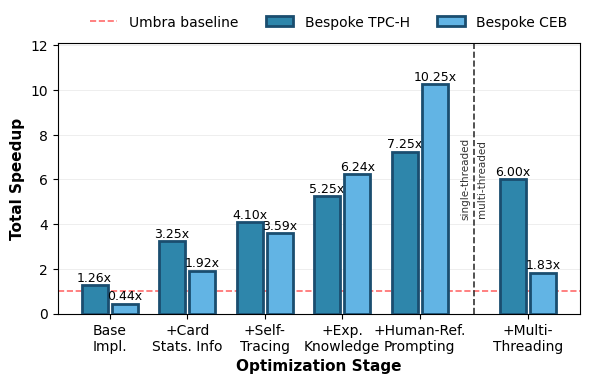

In [46]:
import importlib

import demo_and_analysis.plots.utils.per_stage_plot

importlib.reload(demo_and_analysis.plots.utils.per_stage_plot)

from demo_and_analysis.plots.utils.per_stage_plot import plot_ablation

plot_ablation(
    all_stage_speedups, runs, run_info, stages, total_speedup_key, cmp_system="Umbra"
)

/home/jwehrstein/bespoke_olap/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/jwehrstein/bespoke_olap/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/jwehrstein/bespoke_olap/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


Saved: figures/ablation_per_query_Bespoke_TPC-H_tpch_sf20.pdf


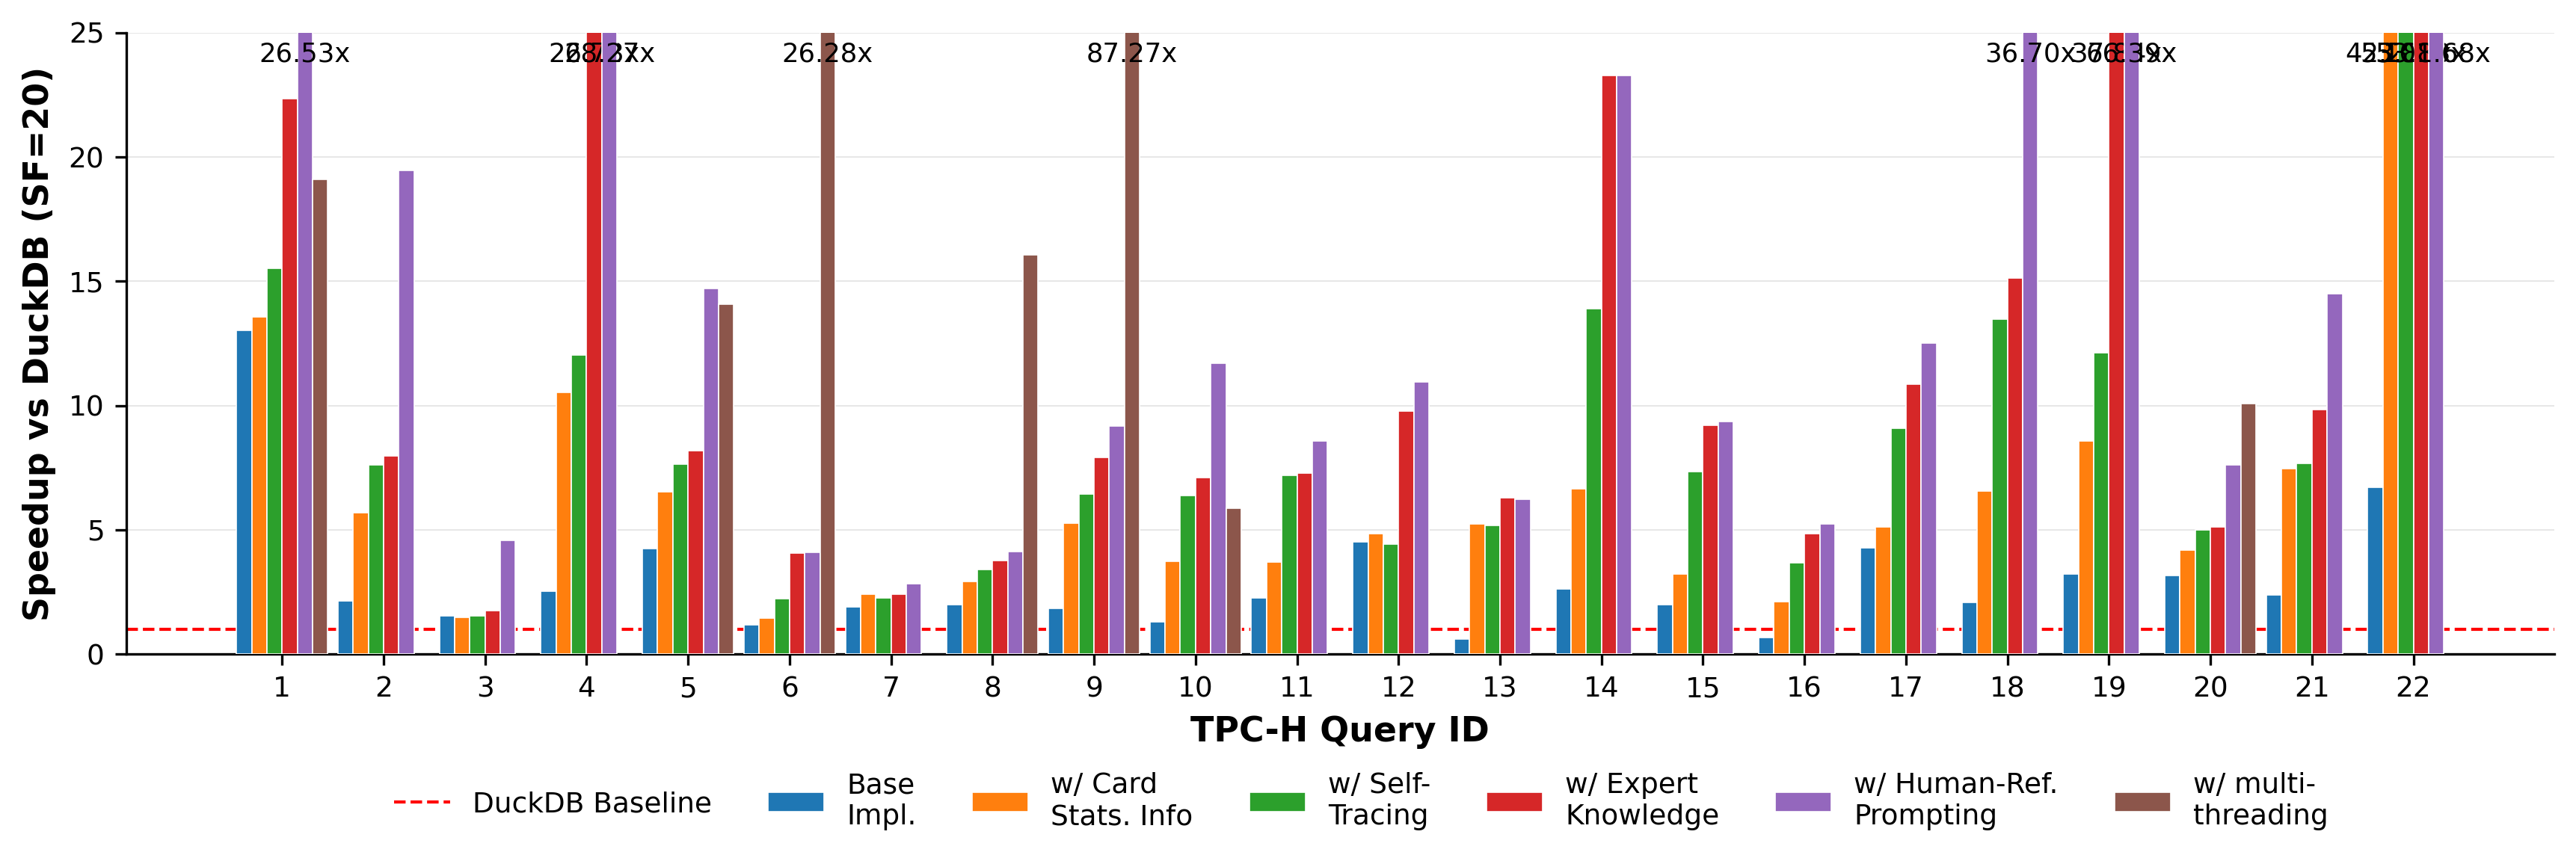

/home/jwehrstein/bespoke_olap/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/jwehrstein/bespoke_olap/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


Saved: figures/ablation_per_query_Bespoke_CEB_ceb_sf2.pdf


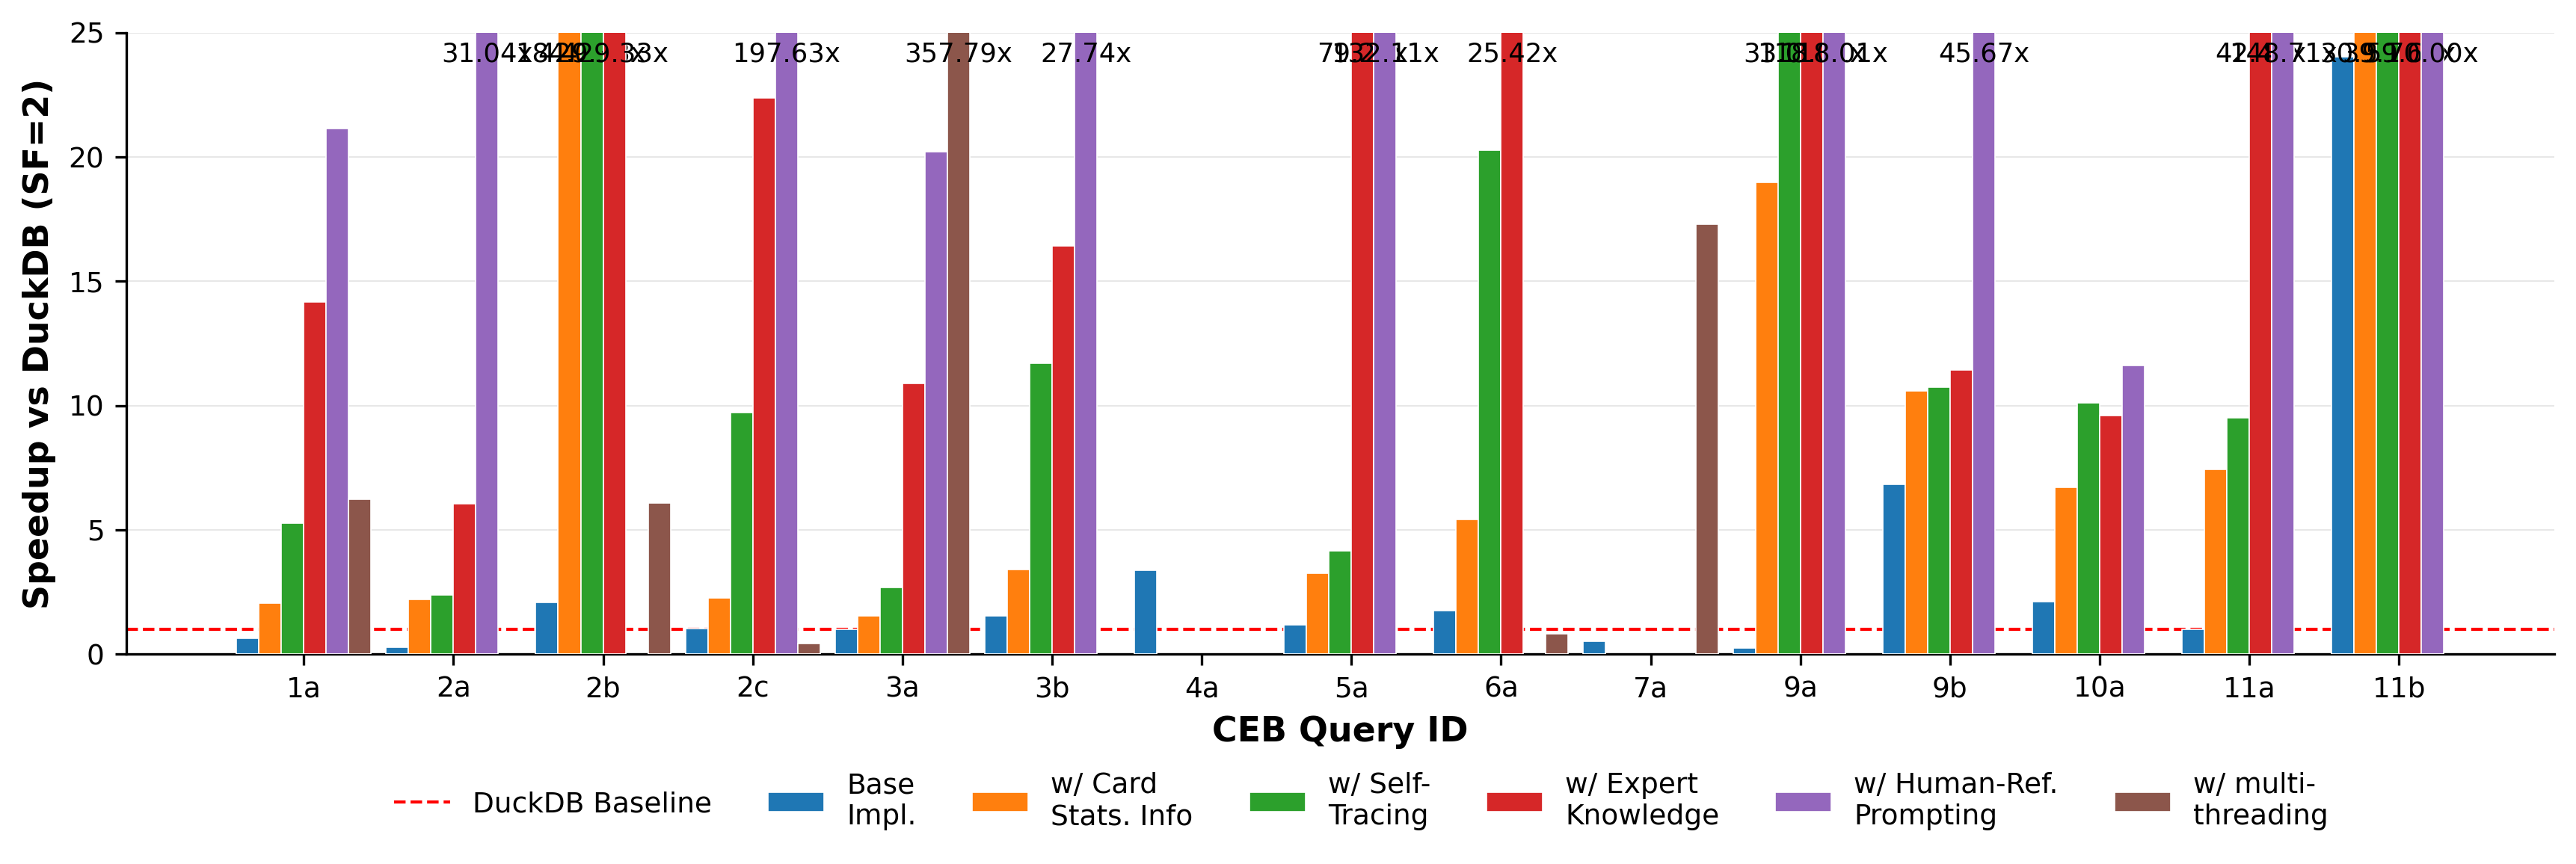

In [9]:
from demo_and_analysis.plots.utils.per_stage_plot import (
    plot_per_query_and_stage_speedups,
)

plot_per_query_and_stage_speedups(
    all_stage_speedups, run_info, stages, benchmark_name_dict
)

Saved: figures/ablation_runtime_per_query_Bespoke_TPC-H_tpch_sf20.pdf


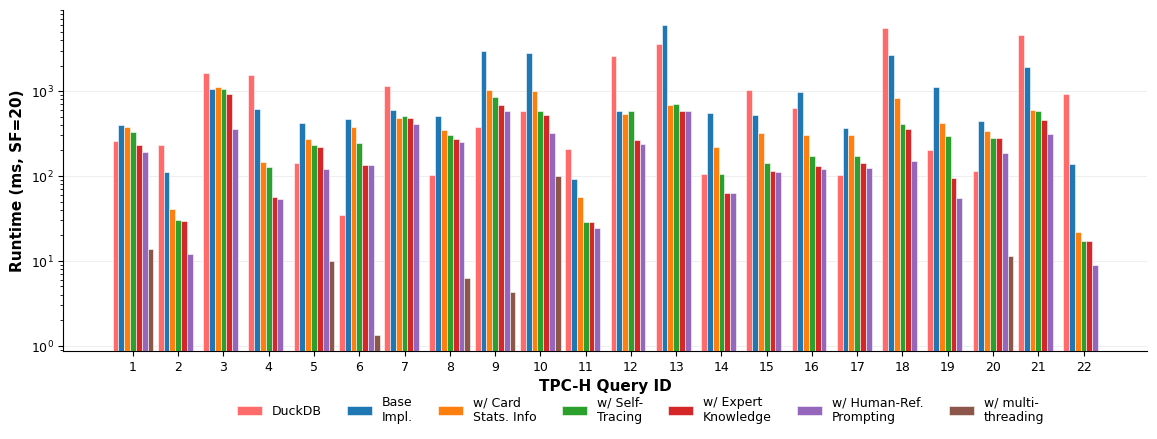

Saved: figures/ablation_runtime_per_query_Bespoke_CEB_ceb_sf2.pdf


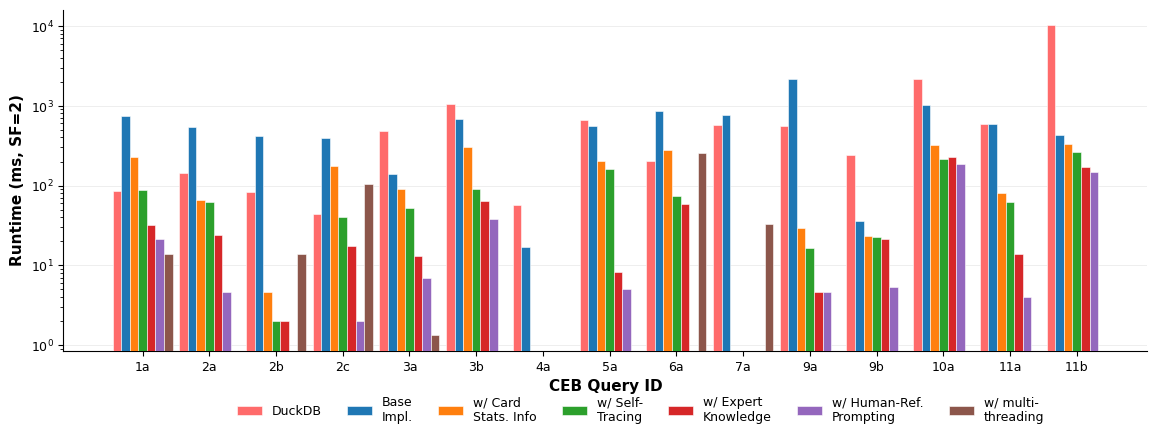

In [10]:
from demo_and_analysis.plots.utils.per_stage_plot import (
    plot_per_query_and_stage_runtimes,
)

plot_per_query_and_stage_runtimes(history_dict, run_info, benchmark_name_dict, stages)